In [1]:
import utils
import models
import dataset
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
X, Y = dataset.load_data(velocity = False, downsample=50, lag = 5)
X_train, Y_train, X_test, Y_test = dataset.partition_data(X, Y, split_ratio = [.8, .2])


Epoch 1/10 | Train Loss: 0.7988 | Val Loss: 1.2558
Epoch 3/10 | Train Loss: 0.6378 | Val Loss: 1.0493
Epoch 5/10 | Train Loss: 0.5463 | Val Loss: 0.8586
Epoch 7/10 | Train Loss: 0.4914 | Val Loss: 0.7337
Epoch 9/10 | Train Loss: 0.4568 | Val Loss: 0.6621
Epoch 10/10 | Train Loss: 0.4429 | Val Loss: 0.6362
Fold 1 Correlation: 0.6658357135121311
Epoch 1/10 | Train Loss: 0.8010 | Val Loss: 0.7306
Epoch 3/10 | Train Loss: 0.5620 | Val Loss: 0.6248
Epoch 5/10 | Train Loss: 0.4617 | Val Loss: 0.5872
Epoch 7/10 | Train Loss: 0.4149 | Val Loss: 0.5760
Epoch 9/10 | Train Loss: 0.3857 | Val Loss: 0.5659
Epoch 10/10 | Train Loss: 0.3736 | Val Loss: 0.5418
Fold 2 Correlation: 0.786916796572458
Epoch 1/10 | Train Loss: 0.7835 | Val Loss: 0.6230
Epoch 3/10 | Train Loss: 0.4995 | Val Loss: 0.4984
Epoch 5/10 | Train Loss: 0.4279 | Val Loss: 0.4268
Epoch 7/10 | Train Loss: 0.3925 | Val Loss: 0.3760
Epoch 9/10 | Train Loss: 0.3703 | Val Loss: 0.3423
Epoch 10/10 | Train Loss: 0.3630 | Val Loss: 0.3267
Fo

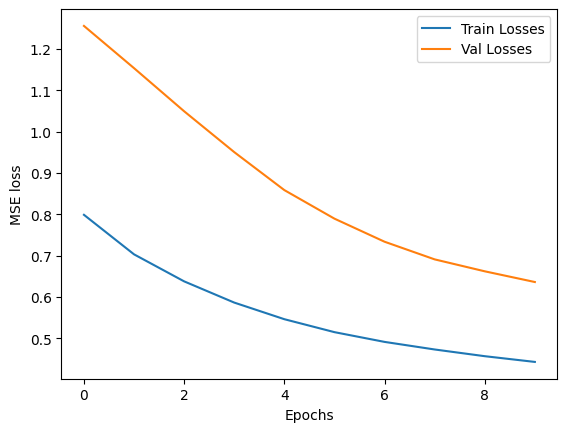

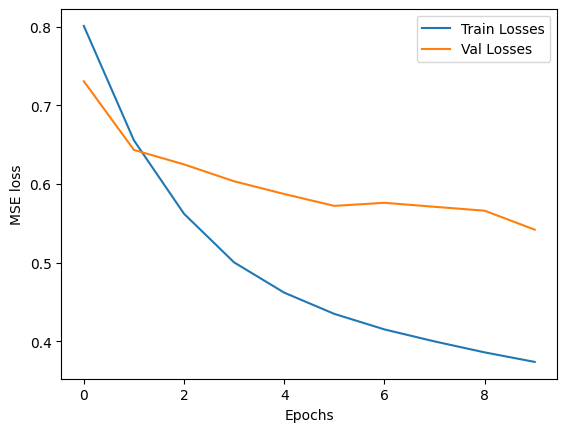

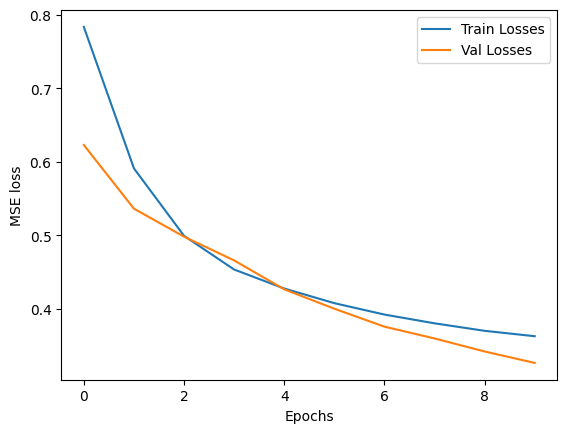

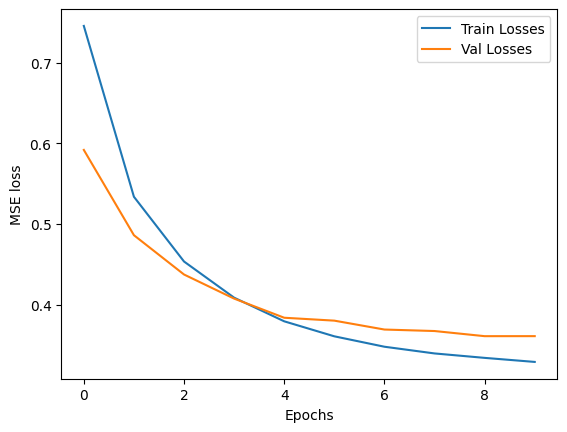

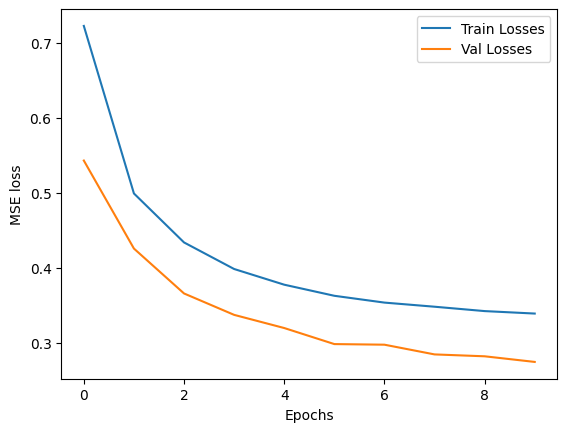

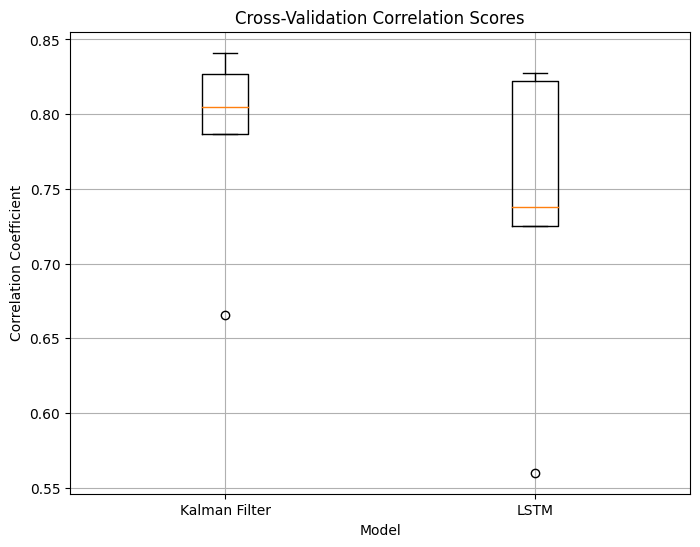

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, KFold
import numpy as np
kf_splitter = TimeSeriesSplit(n_splits=5)

def cv_correl(X,Y,model):
    fold_corrs = []

    for fold, (train_idx, test_idx) in enumerate(kf_splitter.split(X), start=1):
        X_train_fold, Y_train_fold = X[train_idx].copy(), Y[train_idx].copy()
        X_test_fold,  Y_test_fold  = X[test_idx].copy(),  Y[test_idx].copy()

        kf = model
        kf.train_model(X_train_fold, Y_train_fold)
        Y_hat_fold = kf.run_model(X_test_fold)
        current_corr = np.corrcoef(Y_hat_fold.flatten(), Y_test_fold.flatten())[0, 1]
        print(f"Fold {fold} Correlation: {current_corr}")
        fold_corrs.append(current_corr)
    return fold_corrs
nets = [models.MLP(), models.LSTM(), models.KalmanFilter(), models.RidgeRegression(), models.KalmanNet()]
correls = []
for model in nets:
    fold_corrs = cv_correl(X_train, Y_train, model)
    correls.append(fold_corrs)

plt.figure(figsize=(8, 6))
plt.boxplot(correls, labels=["MLP", "LSTM", "KF", "Ridge Regression", "KalmanNet"])
plt.title('Cross-Validation Correlation Scores')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Model')
plt.grid(True)
plt.show()


In [3]:
kf = models.KalmanFilter()
kf.train_model(X_train, Y_train)
kf_yhat = kf.run_model(X_test, Y_test[0, :])


c:\Users\Jjmas\OneDrive\Desktop\EECS 545\EECS545FinalProject\models.py:204: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  self.theta, _, _, _ = np.linalg.lstsq(np.matmul(X.T, X) + self.lbda*np.eye(X.shape[1]), np.matmul(X.T, Y))


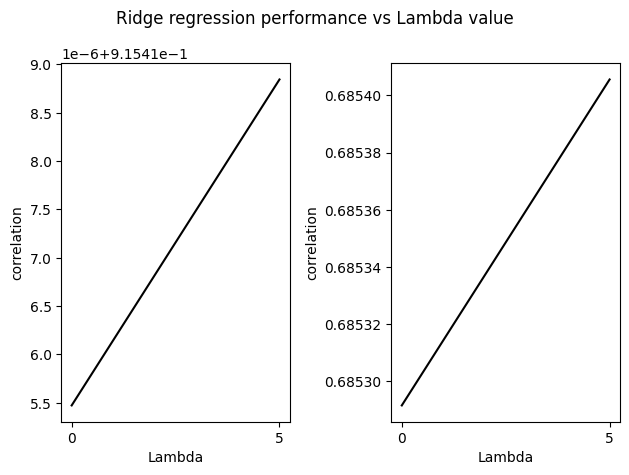

In [4]:
rr = models.RidgeRegression()
rr.train_model(X_train, Y_train)
rr_yhat = rr.run_model(X_test, Y_test[0, :])


In [5]:
nn = models.LSTM()
nn.train_model(X_train, Y_train)
nn_yhat = nn.run_model(X_test)

Epoch 1/10 | Train Loss: 0.9297 | Val Loss: 0.8423
Epoch 3/10 | Train Loss: 0.5169 | Val Loss: 0.5011
Epoch 5/10 | Train Loss: 0.4523 | Val Loss: 0.4469
Epoch 7/10 | Train Loss: 0.3951 | Val Loss: 0.3914
Epoch 9/10 | Train Loss: 0.3513 | Val Loss: 0.3575
Epoch 10/10 | Train Loss: 0.3413 | Val Loss: 0.3467


Epoch 1/10 | Train Loss: 0.6963 | Val Loss: 0.5248
Epoch 3/10 | Train Loss: 0.3999 | Val Loss: 0.3834
Epoch 5/10 | Train Loss: 0.3496 | Val Loss: 0.3525
Epoch 7/10 | Train Loss: 0.3314 | Val Loss: 0.3395
Epoch 9/10 | Train Loss: 0.3228 | Val Loss: 0.3281
Epoch 10/10 | Train Loss: 0.3187 | Val Loss: 0.3297


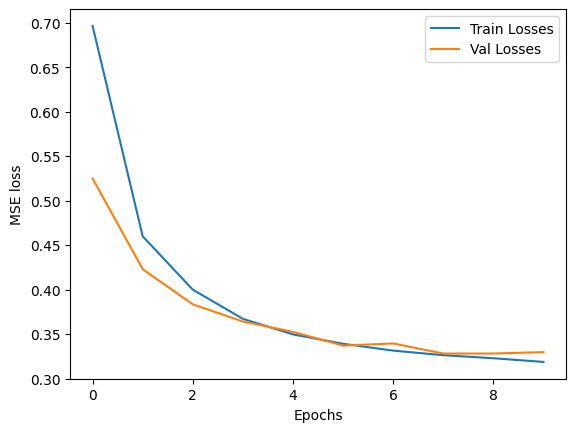

In [6]:
mlp = models.MLP()
mlp.train_model(X_train, Y_train)
mlp_yhat = mlp.run_model(X_test)


In [7]:
knet = models.KalmanNet()
knet.train_model(X_train, Y_train)
knet_yhat = knet.run_model(X_test, Y_test[0, :])


c:\Users\Jjmas\miniconda3\envs\eecs545\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([2])) that is different to the input size (torch.Size([64, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Jjmas\miniconda3\envs\eecs545\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([2])) that is different to the input size (torch.Size([28, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/10, Loss: 38.0257
Epoch 2/10, Loss: 27.9750
Epoch 3/10, Loss: 26.8661
Epoch 4/10, Loss: 25.9211
Epoch 5/10, Loss: 24.8724
Epoch 6/10, Loss: 24.1734
Epoch 7/10, Loss: 23.5029
Epoch 8/10, Loss: 24.0072
Epoch 9/10, Loss: 23.6649
Epoch 10/10, Loss: 23.0748


NameError: name 'plt' is not defined

In [ ]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
end_plot = 500
start = 100

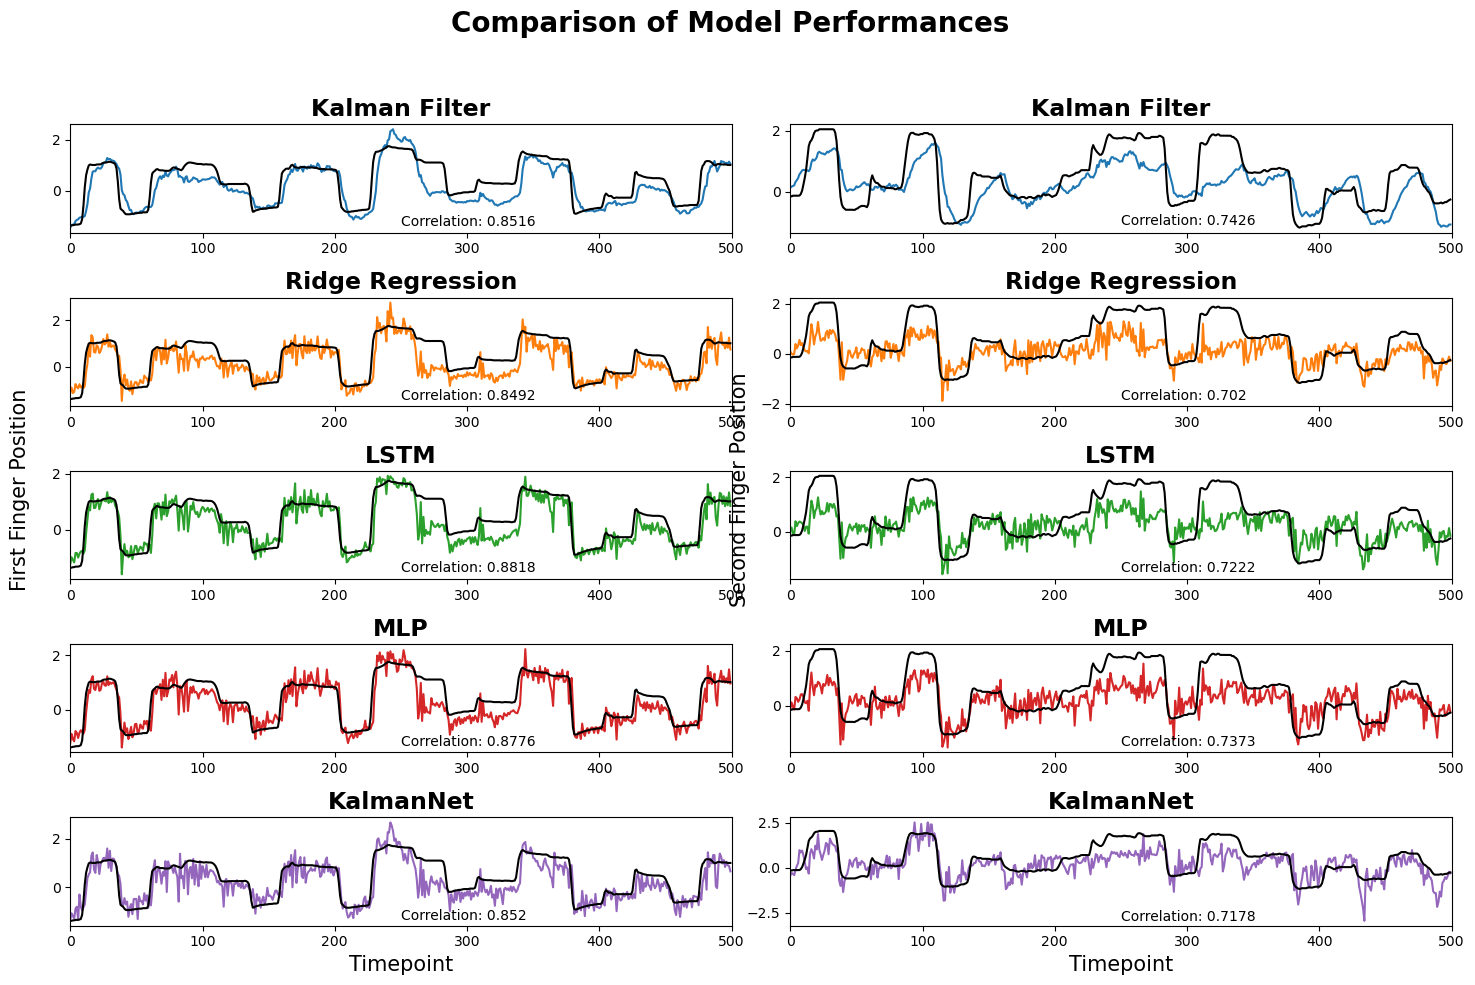

In [ ]:
utils.compare_perfs(Y_test, [kf_yhat, rr_yhat, nn_yhat, mlp_yhat, knet_yhat], model_labels = ["Kalman Filter", "Ridge Regression", "LSTM", "MLP", "KalmanNet"], colors = colors, start = start, end = start + end_plot)